<a href="https://colab.research.google.com/github/Ira9181/iris-classification/blob/main/iris.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#cell:1 importing all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

print("all libraries imported successfully!")

all libraries imported successfully!


In [ ]:
#cell:2 load the iris dataset
iris=load_iris()
#convert to pandas dataframe (like a spreadsheet)
df=pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"]=[iris.target_names[t] for t in iris.target]
#look at the 1st 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
#cell:3 Explore the data
#how many rows and columns?
print("Shape:", df.shape)
#how many flowers of each species?
print (df["species"].value_counts())
#summary statistics
df.describe()

Shape: (150, 5)
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


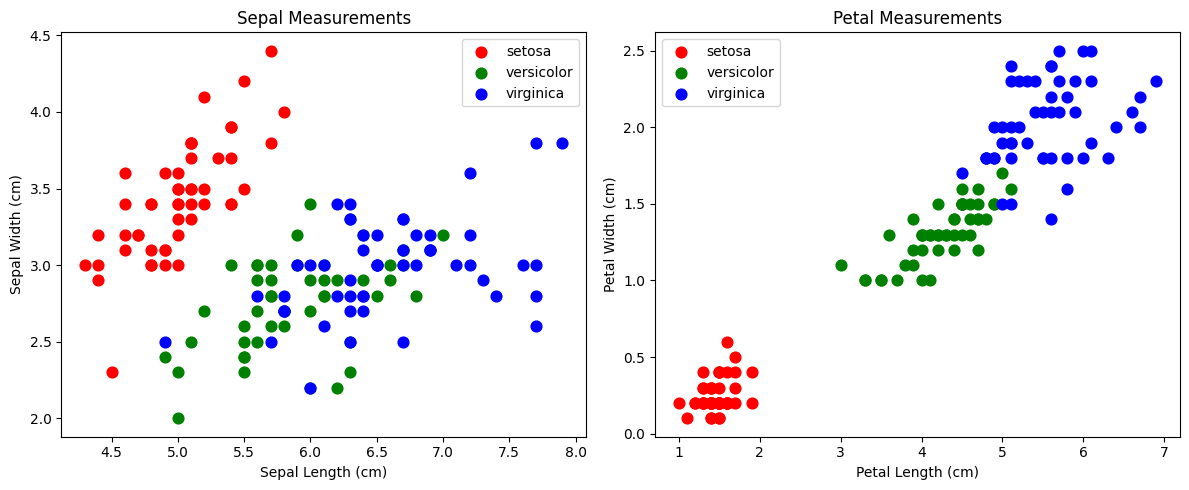

In [ ]:
#cell:4 Scatter plots
colors_map={"setosa":"red", "versicolor":"green", "virginica":"blue"}
fig, axes =plt.subplots(1, 2, figsize=(12,5))
#plot 1:sepal measurements
for species, color in colors_map.items():
  mask=df["species"]==species
  axes[0].scatter(df[mask]["sepal length (cm)"],
                  df[mask] ["sepal width (cm)"],
                  c=color, label=species, s=60)
axes[0].set_xlabel("Sepal Length (cm)")
axes[0].set_ylabel("Sepal Width (cm)")
axes[0].set_title("Sepal Measurements")
axes[0].legend()

# Plot 2: Petal measurements
for species, color in colors_map.items():
  mask = df["species"] == species
  axes[1].scatter(df[mask]["petal length (cm)"],
                  df[mask]["petal width (cm)"],
                  c=color, label=species, s=60)
axes[1].set_xlabel("Petal Length (cm)")
axes[1].set_ylabel("Petal Width (cm)")
axes[1].set_title("Petal Measurements")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
# Cell 5: Separate features and labels
# X = the 4 measurement columns (what the model USES to predict)
X = iris.data # shape: (150, 4)

# y = the species number (what we want to PREDICT)
# 0 = setosa, 1 = versicolor, 2 = virginica
Y= iris.target # shape: (150,)

print("Features shape:", X.shape)
print("Labels shape:", Y.shape)

Features shape: (150, 4)
Labels shape: (150,)


In [ ]:
#Cell 6: Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
  X, # features
  Y, # labels
  test_size=0.2, # 20% for testing
  random_state=42 # fixes the random seed so results are repeatable
  )
print("Training samples:", len(X_train)) # 120
print("Test samples: ", len(X_test)) # 30

Training samples: 120
Test samples:  30


In [ ]:
#Cell 7: Feature scaling
scaler = StandardScaler()
# IMPORTANT: fit_transform on TRAIN, only transform on TEST
# (The scaler learns the average from training data only)
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print("Scaling complete!")
11 # Each feature now has mean » 0 and standard deviation » 1

Scaling complete!


11

In [ ]:
#Cell 8: Train KNN model
# Create the model (K=3 means: look at 3 nearest neighbours)
knn = KNeighborsClassifier(n_neighbors=3)
# Train it (this is where the "learning" happens)
knn.fit(X_train, y_train)
print("KNN model trained!")

KNN model trained!


In [ ]:
#Cell 9: Train Logistic Regression model
lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)

print("Logistic Regression model trained!")

Logistic Regression model trained!


In [ ]:
#Cell 10: Evaluate both models
# Make predictions on test set
knn_predictions = knn.predict(X_test)
lr_predictions = lr.predict(X_test)
# Calculate accuracy
knn_acc = accuracy_score(y_test, knn_predictions)
lr_acc = accuracy_score(y_test, lr_predictions)
print(f"KNN Accuracy: {knn_acc * 100:.1f}%")
print(f"Logistic Regression Accuracy: {lr_acc * 100:.1f}%")


KNN Accuracy: 100.0%
Logistic Regression Accuracy: 100.0%


In [ ]:
#Cell 11: Confusion matrix
cm = confusion_matrix(y_test, knn_predictions)
print("Confusion Matrix (KNN):")
print(cm)
# Pretty print with species names
import pandas as pd
species = iris.target_names
cm_df = pd.DataFrame(cm, index=species, columns=species)
print(cm_df)

Confusion Matrix (KNN):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
            setosa  versicolor  virginica
setosa          10           0          0
versicolor       0           9          0
virginica        0           0         11


In [ ]:
#Cell 12: Predict a new flower
# A new flower: sepal_length, sepal_width, petal_length, petal_width
new_flower = [[5.1, 3.5, 1.4, 0.2]] # These look like a Setosa!

# Scale the new flower using the SAME scaler (not a new one!)
new_flower_scaled = scaler.transform(new_flower)
# Predict with both models
knn_result = knn.predict(new_flower_scaled)
lr_result = lr.predict(new_flower_scaled)

print("KNN predicts: ", iris.target_names[knn_result[0]])
print("Logistic Regression predicts:", iris.target_names[lr_result[0]])

# Output: setosa (both agree!)

KNN predicts:  setosa
Logistic Regression predicts: setosa


In [ ]:
#Cell 13: Prediction probabilities

# How confident is the model?
proba = lr.predict_proba(new_flower_scaled)

for species, prob in zip(iris.target_names, proba[0]):
  print(f"{species:12s}: {prob*100:.1f}%")


setosa      : 97.9%
versicolor  : 2.1%
virginica   : 0.0%
